In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [3]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra, StatsBase;

┌ Info: Precompiling JJDFTX [0d21db8c-e7cb-497b-98f4-4306b49e2569]
└ @ Base loading.jl:1317


Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [28]:
graphene_epsilon = zeros(100, 1000)
for i in 1:100
    for j in 1:1000
        graphene_epsilon[i, j] = JJDFTX.exact_graphene_epsilon(1/6*i/100, j/1000*2, 1)
    end
end

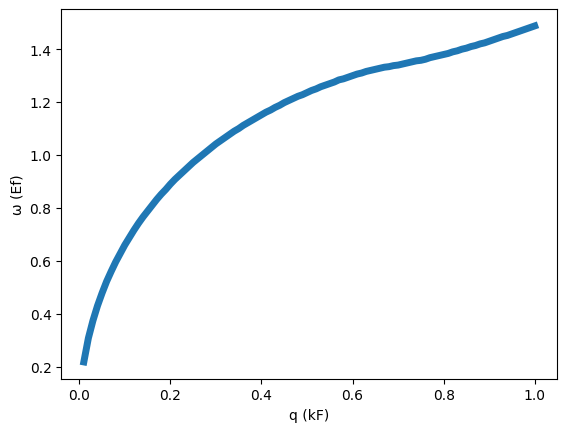

PyObject Text(24.000000000000007, 0.5, 'ω (Ef)')

In [34]:
plot(range(1/100, 1, length=100), [argmin(r)*2/1000 for r in eachrow(log.(abs.(graphene_epsilon)))], linewidth=5)
xlabel("q (kF)")
ylabel("ω (Ef)")

In [62]:
N=100
graphene_epsilon_numerical = zeros(N, N)
for i in 1:N
    for j in 1:N
        graphene_epsilon_numerical[i, j] = JJDFTX.graphene_epsilon(1, 1/6*i/N, 2*j/N, maxevals=200000)
    end
end

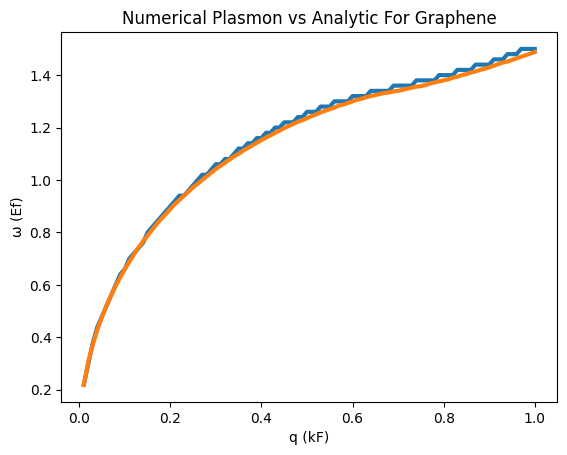

PyObject Text(0.5, 1.0, 'Numerical Plasmon vs Analytic For Graphene')

In [75]:
plot(range(1/N, 1, length=N), [argmin(r)*2/N for r in eachrow(log.(abs.(graphene_epsilon_numerical)))], linewidth=3)
plot(range(1/100, 1, length=100), [argmin(r)*2/1000 for r in eachrow(log.(abs.(graphene_epsilon)))], linewidth=3)
xlabel("q (kF)")
ylabel("ω (Ef)")
title("Numerical Plasmon vs Analytic For Graphene")

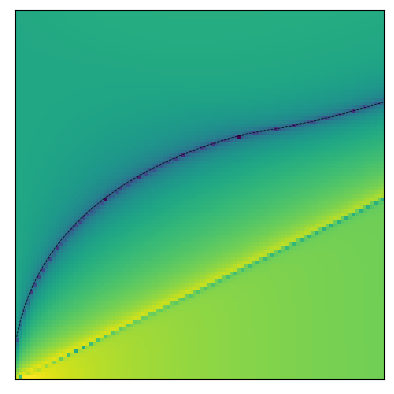

(Any[], Any[])

In [152]:
imshow(log.(abs.(transpose(graphene_epsilon_numerical))), origin="lower")
plot([argmin(r)/10 for r in eachrow(log.(abs.(graphene_epsilon)))], linewidth=0.5, color="black", linestyle="dashed")

#plot()
xticks(Float64[])
yticks(Float64[])

In [109]:
graphene_real_conductivities = zeros(50)

for i in 1:50
    graphene_real_conductivities[i]  = imag(JJDFTX.graphene_conductivity(1, 1/50, 3*i/50, maxevals=100000))
end

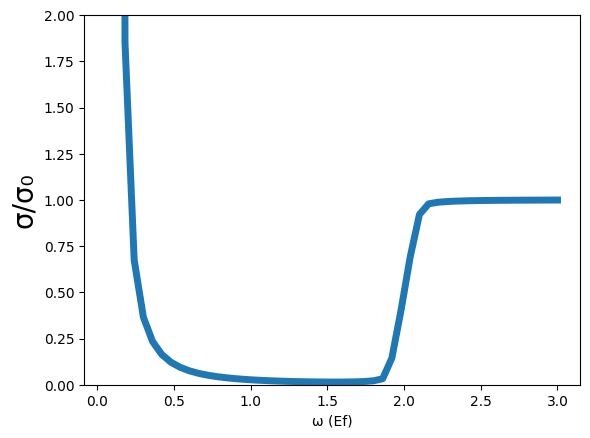

PyObject Text(38.0, 0.5, 'σ/σ₀')

In [132]:
plot(range(3/50, 3, length=50), graphene_real_conductivities, linewidth=5)
ylim(0, 2)
xlabel("ω (Ef)")
ylabel("σ/σ₀", fontsize=20)

In [148]:
omegas, c = JJDFTX.graphene_histogram_conductivity(1, 1/100, mesh=10000)

([0.0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009  …  4.991, 4.992, 4.993, 4.994, 4.995, 4.996, 4.997, 4.998, 4.999, 5.0], [0.000605515321448864, 0.013940958988949542, 0.04842485045315543, 0.1112958195782894, 0.18762298553965198, 0.3016621362634935, 0.4365330196565967, 0.5803802546311714, 0.7594957614978642, 0.971642837930372  …  1.001595644647478, 0.9972295855027625, 1.002096807024321, 1.0010645296531895, 0.9979132966346793, 1.001733336107173, 1.0008687378141465, 0.9979465317201085, 1.001841600307217, 0.49892696530191777])

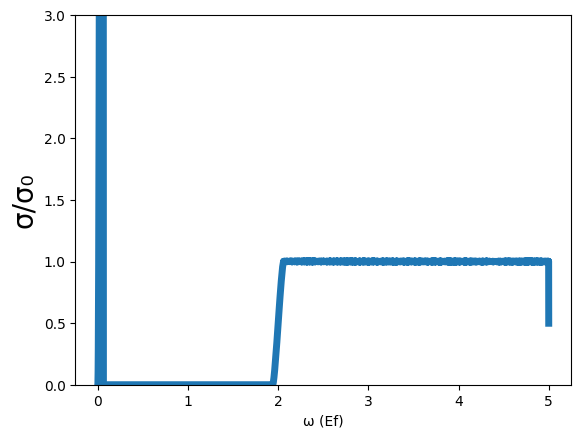

PyObject Text(0.5, 24.0, 'ω (Ef)')

In [151]:
plot(omegas, c, linewidth=5)
ylim(0, 3)
ylabel("σ/σ₀", fontsize=20)
xlabel("ω (Ef)")


In [164]:
g_dos = JJDFTX.graphene_dos(2.7, 1000, 100);

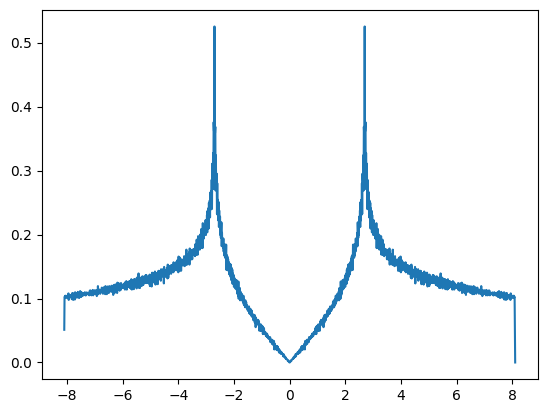

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7ff6db969610>

In [286]:
plot(range(-2.7*3, 2.7*3, length=length(g_dos)), g_dos)

In [187]:
g_dos_quad = JJDFTX.graphene_dos_quad.(2.7, range(0, 2.7*3, length=100), 0.1, maxevals=100000)

100-element Vector{Float64}:
 0.007049822345936601
 0.009610149503179774
 0.012845007132252624
 0.016408630637307946
 0.020157397248222516
 0.02403368907217989
 0.028012864949966614
 0.032085005316574725
 0.03624784644851637
 0.04050371121097165
 0.04485806300476489
 0.04931881853216801
 0.05389606456304069
 ⋮
 0.10469196163173088
 0.10374466171057976
 0.10273198448205341
 0.1016255436322949
 0.10038153381703406
 0.09892860102873992
 0.09714243147851027
 0.09478707236554025
 0.09136199703914998
 0.08564584138593748
 0.07429312355357404
 0.05167996658797615

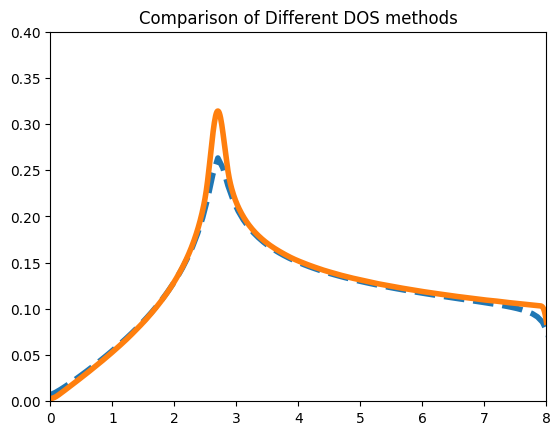

PyObject Text(0.5, 1.0, 'Comparison of Different DOS methods')

In [201]:
plot(range(0, 2.7*3, length=100), g_dos_quad, linewidth=4, linestyle="dashed")
plot(range(-2.7*3, 2.7*3, length=length(g_dos)), smooth(g_dos), linewidth=4)
xlim(0, 8)
ylim(0, 0.4)
title("Comparison of Different DOS methods")

In [ ]:
# Demonstrating Kramers Kronig Implementation

In [252]:
q=1/100
N=200
rpol_kk = zeros(N)
rpol = zeros(N)

for i in 10:N
    rpol_kk[i] = kramers_kronig(ω->JJDFTX.graphene_total_impolarization(q, ω, 1), 2*i/50, 60, min_energy_integration=0)
    rpol[i] = graphene_total_polarization(q, 2*i/50, 1)
end


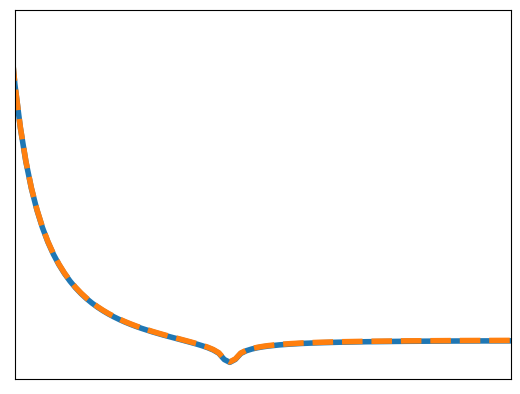

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7ff6db7aab80>

In [284]:
plot(rpol, linewidth=4)
#xlim(30, 40)
xlim(10, 100)
#ylim(-0.0005, 0.0005)
xticks(Float64[])
yticks(Float64[])
plot(rpol_kk, linestyle="dashed", linewidth=4)

In [277]:
q=1/3
N=400
impol_kk = zeros(N)
impol = zeros(N)

for i in 60:N
    impol_kk[i] = kramers_kronig_reverse(ω->JJDFTX.graphene_total_polarization(q, ω, 1), 2*i/50,  60000)
    impol[i]  = graphene_total_impolarization(q, 2*i/50, 1)
end

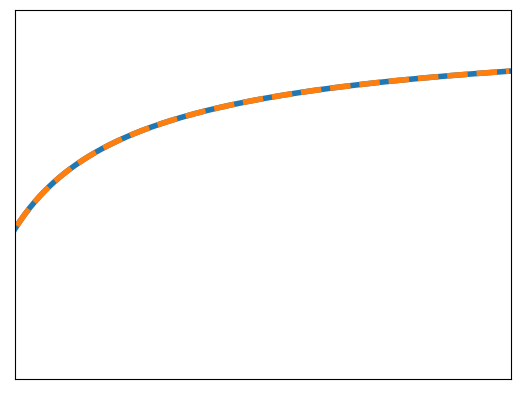

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7ff6af179a90>

In [283]:
plot(impol, linewidth=4)
yticks(Float64[])
xlim(100, 400)
xticks(Float64[])
#ylim(-0.0005, 0.0005)
plot(impol_kk, linestyle="dashed", linewidth=4)

In [287]:
# Checking Self Energies

In [12]:
graphene_numerical_self = JJDFTX.graphene_numerical_self_energy(1, mesh1=3000, mesh2=3000, histogram_width=100, verbose=false);

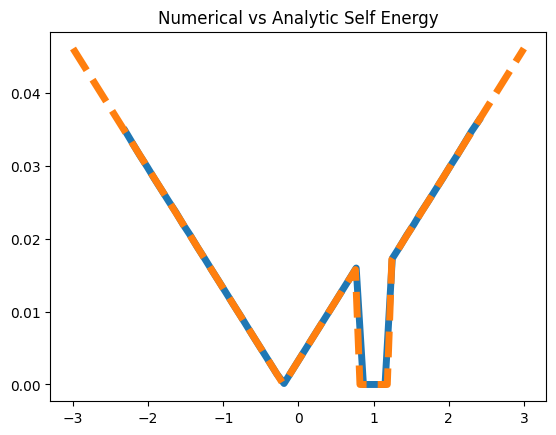

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fedf100c3a0>

In [17]:
plot((collect(1:50) .- 50/2)/50*0.8*6,  graphene_numerical_self, linewidth=5)
title("Numerical vs Analytic Self Energy")
xlabel("")
plot(range(-3, 3, length=100), JJDFTX.graphene_electron_self_energy.(range(-3, 3, length=100), 1, prefactor=0.016485798381445285), linestyle="dashed", linewidth=5)

In [27]:
graphene_numerical_real_self = JJDFTX.graphene_electron_real_self_energy.(-3:0.02:3, 1, 8.4)

301-element Vector{Float64}:
  0.034305843991497505
  0.034339892917317275
  0.03437162624145594
  0.0344010401041119
  0.034428130426716726
  0.03445289290935814
  0.034475323028102925
  0.03449541603218288
  0.03451226599721438
  0.03452857054136143
  0.0345416213836775
  0.03455231377922405
  0.03456064154668598
  ⋮
 -0.034925040936033665
 -0.03490786090978654
 -0.03488849896958433
 -0.03486695419792967
 -0.034843225772751556
 -0.034817312918188424
 -0.03478921490803368
 -0.034758931049433346
 -0.03472646067170119
 -0.0346918031140848
 -0.03465495771683165
 -0.03461592381107417

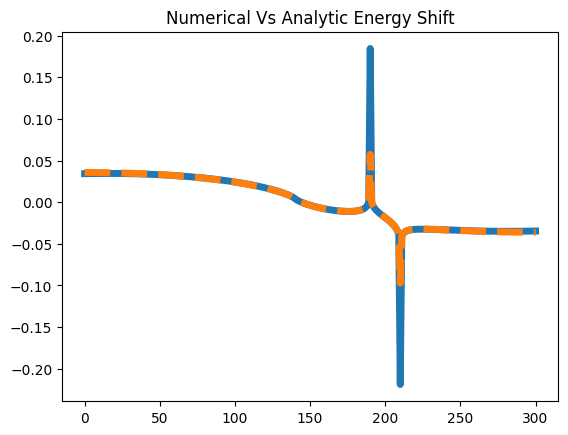

PyObject Text(0.5, 1.0, 'Numerical Vs Analytic Energy Shift')

In [33]:
plot(graphene_numerical_real_self, linewidth=5)
plot(JJDFTX.graphene_analytic_real_self_energy.(-3:0.02:3, 1), linestyle="dashed", linewidth=5)
title("Numerical Vs Analytic Energy Shift")